In [84]:
# fetching list of barcodes from link provided

import requests

barcodes_link = "https://github.com/f0t1h/3M-february-2018/raw/refs/heads/master/3M-february-2018.txt.gz"
filename = "data/3M-february-2018.txt.gz"

try:
    response = requests.get(barcodes_link, stream=True)
    response.raise_for_status()  # Raise an exception for bad status codes (4xx or 5xx)

    with open(filename, 'wb') as f:
        for chunk in response.iter_content(chunk_size=8192):
            f.write(chunk)
    print(f"File '{filename}' downloaded successfully.")

except requests.exceptions.RequestException as e:
    print(f"Error downloading the file: {e}")

File 'data/3M-february-2018.txt.gz' downloaded successfully.


# Alevin-fry pipeline
- Followed the steps outlined by https://www.sc-best-practices.org/introduction/raw_data_processing.html#a-real-world-example (section 3.8)
1. First build the splici reference using pyroe make-splici
2. Then index the splici reference using salmon index

In [85]:
%%bash
# unzip downloaded file
gunzip data/3M-february-2018.txt.gz
ls -l data

# ref_dir=data/toy_ref_read/toy_human_ref
# pyroe make-splici ${ref_dir}/fasta/genome.fa ${ref_dir}/genes/genes.gtf 90 splici_rl90_ref

# salmon index -t splici_rl90_ref/*.fa -i salmon_index -p 8

Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.


# Mapping & Quantification
- Map sequencing reads against the splici index

In [14]:
# %%bash
# # Mapping and quantification
# fastq_dir="data/toy_ref_read/toy_read_fastq"
# reads1="selected_R1_reads.fastq"
# reads2="selected_R2_reads.fastq"

# # Mapping
# salmon alevin \
# -i salmon_index \
# -l ISR \
# -1 $fastq_dir/$reads1 \
# -2 $fastq_dir/$reads2 \
# -p 8 \
# -o salmon_alevin \
# --chromiumV3 \
# --sketch

usage: paste [-s] [-d delimiters] file ...
usage: paste [-s] [-d delimiters] file ...


Version Server Response: Not Found
[2025-11-17 07:54:12.181] [alevinLog] [info] currently, --sketch implies --rad. Running in alignment-only mode (will write a RAD output).
Logs will be written to salmon_alevin/logs
[2025-11-17 07:54:12.181] [alevinLog] [info] The --rad flag was passed to alevin. The reads will be selectively aligned and the output written to a RAD file.Arguments passed that correspond to other processing steps will be ignored
[2025-11-17 07:54:12.181] [alevinLog] [info] The --sketch flag was passed; the alignment will be run in sketch mode.
[2025-11-17 07:54:12.188] [jointLog] [info] setting maxHashResizeThreads to 8
[2025-11-17 07:54:12.188] [jointLog] [info] Fragment incompatibility prior below threshold.  Incompatible fragments will be ignored.
[2025-11-17 07:54:12.188] [jointLog] [info] The --mimicBT2, --mimicStrictBT2 and --hardFilter flags imply mapping validation (--validateMappings). Enabling mapping validation.
[2025-11-17 07:54:12.188] [jointLog] [info] Usag

# Cell barcode correction and UMI resolution
Steps:
1. Barcode correction using alevin-fry
2. Filter invalid records, correct cell barcodes, and collate mapping records coming from the same corrected cell barcodes using collate command.
3. UMI resolution and quantification using quant command.

In [16]:
# %%bash
# # Cell barcode correction
# alevin-fry generate-permit-list \
# -u data/3M-february-2018.txt \
# -d fw \
# -i salmon_alevin \
# -o alevin_fry_gpl

# # Filter mapping information
# alevin-fry collate \
# -i alevin_fry_gpl \
# -r salmon_alevin \
# -t 8

# # UMI resolution + quantification
# alevin-fry quant -r cr-like \
# -m $(ls splici_rl90_ref/*3col.tsv) \
# -i alevin_fry_gpl \
# -o alevin_fry_quant \
# -t 8

2025-11-17 08:26:01 INFO reading permit list from data/3M-february-2018.txt; inferred format No
2025-11-17 08:26:03 INFO number of unfiltered bcs read = 6,794,880
2025-11-17 08:26:03 INFO paired : false, ref_count : 337, num_chunks : 7
2025-11-17 08:26:03 INFO read 2 file-level tags
2025-11-17 08:26:03 INFO read 2 read-level tags
2025-11-17 08:26:03 INFO read 1 alignemnt-level tags
2025-11-17 08:26:03 INFO File-level tag values TagMap { keys: [TagDesc { name: "cblen", typeid: Int(U16) }, TagDesc { name: "ulen", typeid: Int(U16) }], dat: [U16(16), U16(12)] }
2025-11-17 08:26:03 INFO observed 33,208 reads (27,554 orientation consistent) in 7 chunks --- max ambiguity read occurs in 24 refs
2025-11-17 08:26:03 INFO The percentage of mapped reads not matching a known barcode exactly is 1.795%, which is < the warning threshold 30.000%
2025-11-17 08:26:03 INFO minimum num reads for barcode pass = 10
2025-11-17 08:26:03 INFO num_passing = 165
2025-11-17 08:26:03 INFO found 165 cells with non-t

In [58]:
# import pyroe
# quant_dir = 'alevin_fry_quant'
# adata = pyroe.load_fry(quant_dir, output_format={'X' : ['U','S','A']})

USA mode: True
Processing user-defined output format.
Will populate output field X with sum of counts frorm ['U', 'S', 'A'].


AttributeError: 'dict' object has no attribute 'output_format'

# Gotcha
The current adata object has as an index Ensembl Gene IDs, this will cause problems later when trying to perform automatic cell annotation using celltypist, which uses gene symbols or names. The gene_id_to_name.tsv file provided by the splici reference can help us map the Ensembl Gene IDs to their symbols.

We can then assign this mapping as the index for the adata object.

In [76]:
# gene_id_to_name = 'splici_rl90_ref/gene_id_to_name.tsv'
# ensemble_to_gene = {}

# with open(gene_id_to_name) as f:
#     for line in f:
#         line = line.strip()
#         ensemble, gene = line.split()
#         ensemble_to_gene[ensemble] = gene

# curr_index = adata.var.index
# new_index = [ensemble_to_gene[e] for e in curr_index]

# adata.var["gene_symbol"] = new_index
# adata.var_names = adata.var["gene_symbol"]

Index(['NDFIP1', 'UBE2D2', 'APC', 'VCAN', 'UBE2B', 'HSPA4', 'CAST', 'PIK3R1',
       'BASP1', 'TNPO1', 'RHOBTB3', 'PPP2CA', 'ZFR', 'MYO10', 'HSPA9', 'MGAT1',
       'IL6ST', 'ETF1', 'PJA2', 'LINC00461'],
      dtype='object', name='gene_symbol') Index(['NDFIP1', 'UBE2D2', 'APC', 'VCAN', 'UBE2B', 'HSPA4', 'CAST', 'PIK3R1',
       'BASP1', 'TNPO1', 'RHOBTB3', 'PPP2CA', 'ZFR', 'MYO10', 'HSPA9', 'MGAT1',
       'IL6ST', 'ETF1', 'PJA2', 'LINC00461'],
      dtype='object', name='gene_symbol')


# Clustering

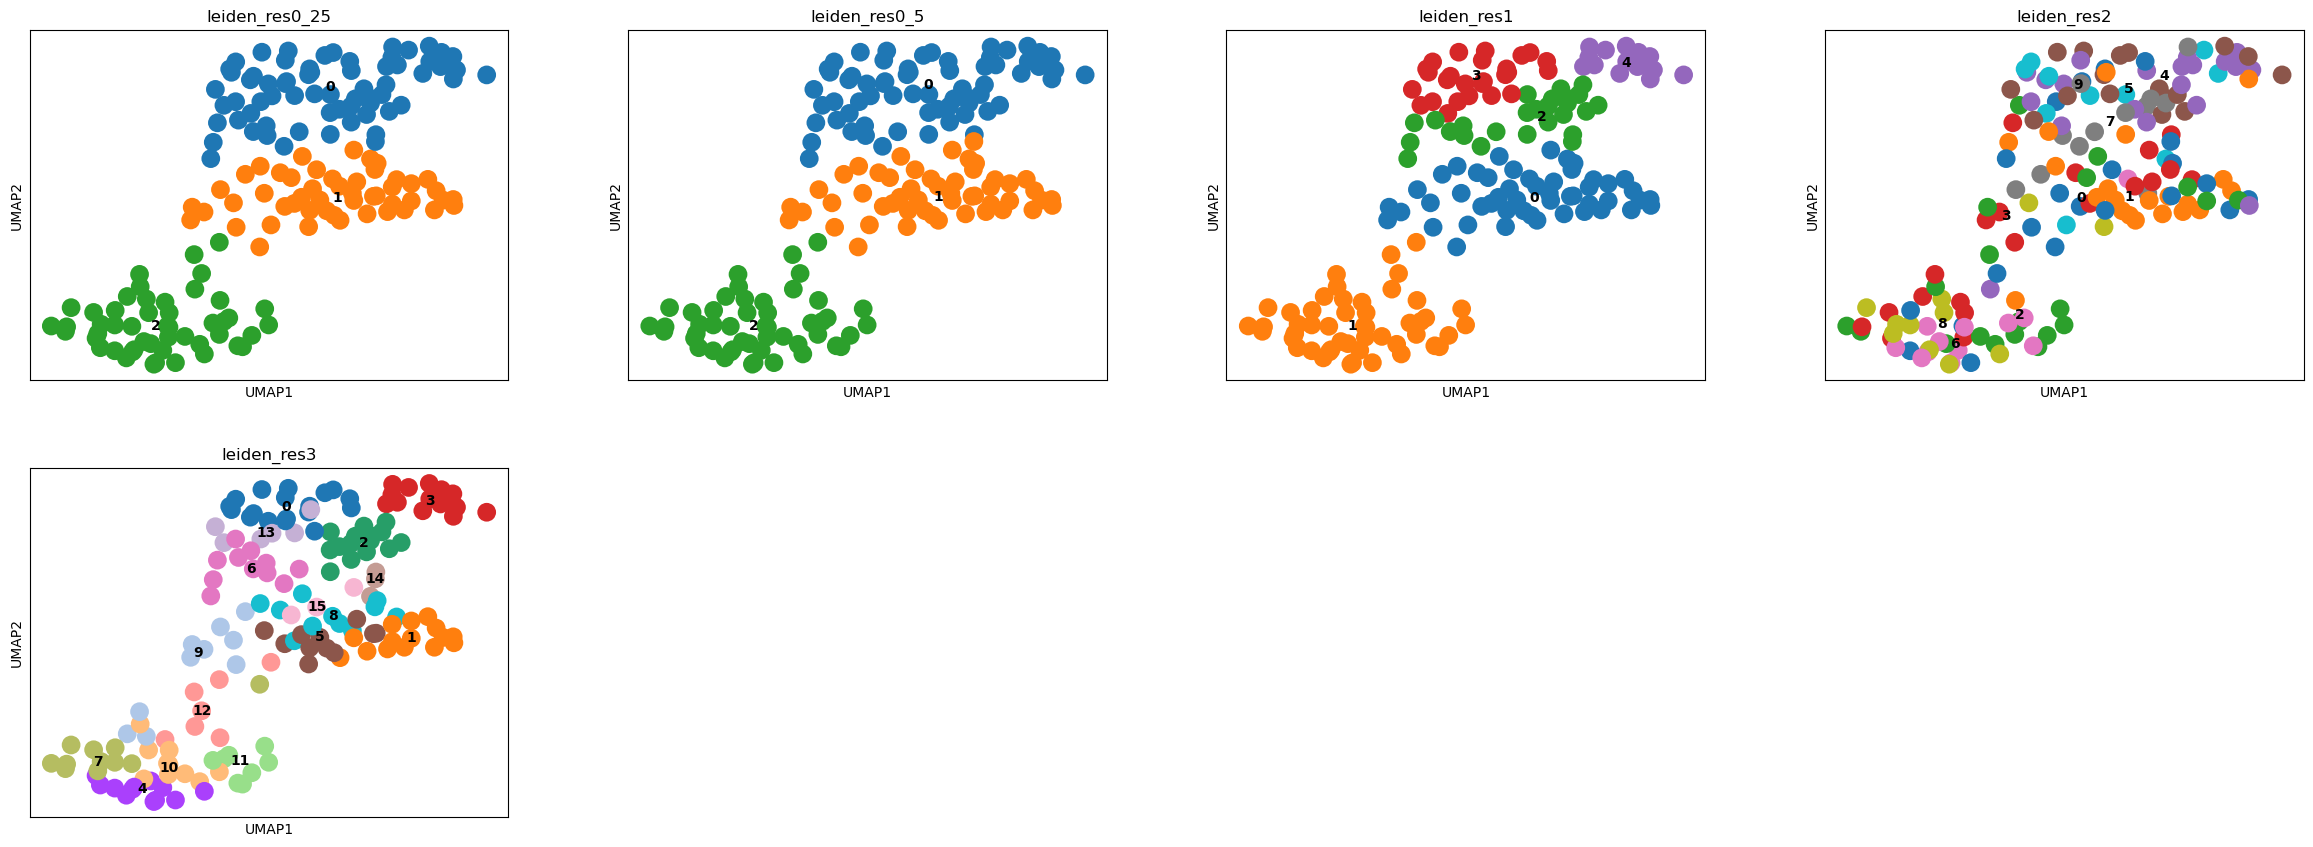

In [80]:
# import scanpy as sc
# sc.pp.neighbors(adata, n_pcs=30)
# sc.tl.umap(adata)

# sc.tl.leiden(adata, key_added="leiden_res0_25", resolution=0.25)
# sc.tl.leiden(adata, key_added="leiden_res0_5", resolution=0.5)
# sc.tl.leiden(adata, key_added="leiden_res1", resolution=1.0)
# sc.tl.leiden(adata, key_added="leiden_res2", resolution=2.0)

# sc.pl.umap(
#     adata,
#     color=["leiden_res0_25", "leiden_res0_5", "leiden_res1", "leiden_res2"],
#     legend_loc="on data",
# )

In [78]:
# # annotating cluster
# adata.layers["counts"] = adata.X
# adata_celltypist = adata.copy()  # make a copy of our adata
# adata_celltypist.X = adata.layers["counts"]  # set adata.X to raw counts
# sc.pp.normalize_total(
#     adata_celltypist, target_sum=10**4
# )  # normalize to 10,000 counts per cell
# sc.pp.log1p(adata_celltypist)  # log-transform
# # make .X dense instead of sparse, for compatibility with celltypist:
# adata_celltypist.X = adata_celltypist.X.toarray()

📜 Retrieving model list from server https://celltypist.cog.sanger.ac.uk/models/models.json
📚 Total models in list: 59
📂 Storing models in /Users/ashleyosuna/.celltypist/data/models
💾 Total models to download: 2
💾 Downloading model [1/2]: Immune_All_Low.pkl
💾 Downloading model [2/2]: Immune_All_High.pkl
🔬 Input data has 165 cells and 20 genes
🔗 Matching reference genes in the model
🧬 10 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 5
🗳️ Majority voting the predictions
✅ Majority voting done!
🔬 Input data has 165 cells and 20 genes
🔗 Matching reference genes in the model
🧬 10 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with r

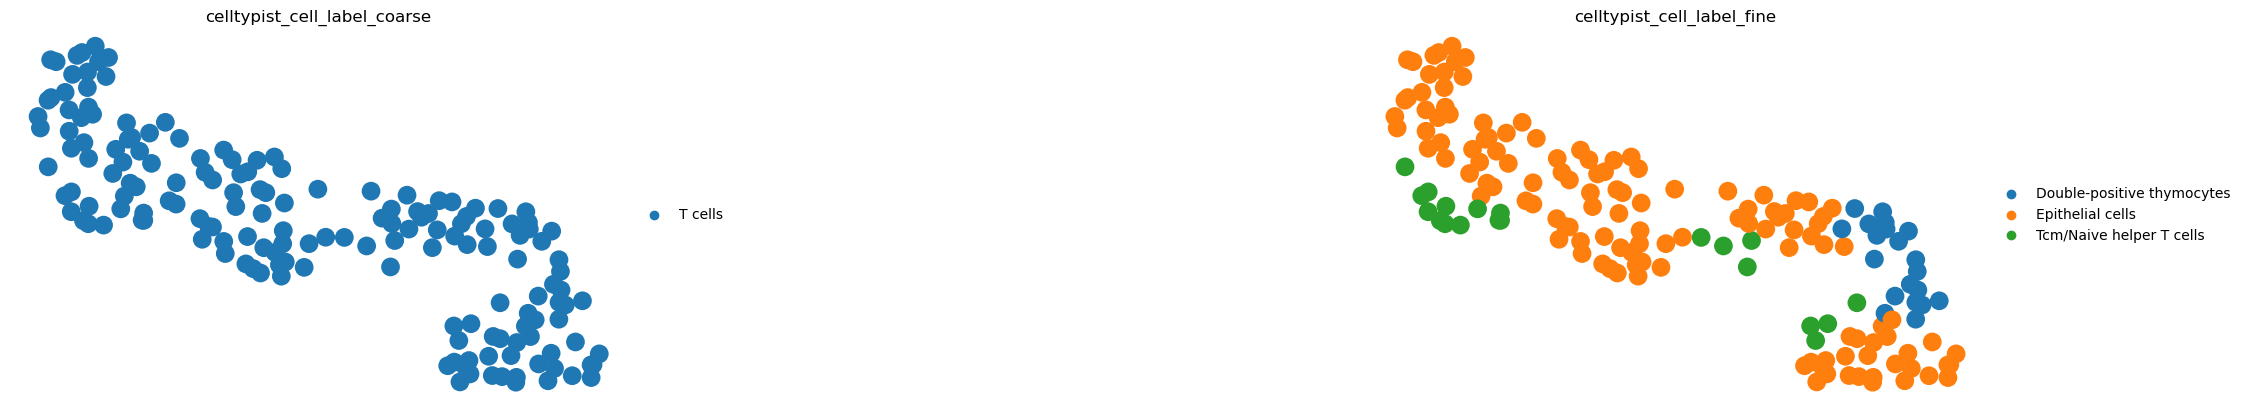

In [79]:
# from celltypist import models
# import celltypist

# models.download_models(
#     force_update=True, model=["Immune_All_Low.pkl", "Immune_All_High.pkl"]
# )

# model_low = models.Model.load(model="Immune_All_Low.pkl")
# model_high = models.Model.load(model="Immune_All_High.pkl")

# predictions_high = celltypist.annotate(
#     adata_celltypist, model=model_high, majority_voting=True
# )

# predictions_high_adata = predictions_high.to_adata()
# adata.obs["celltypist_cell_label_coarse"] = predictions_high_adata.obs.loc[
#     adata.obs.index, "majority_voting"
# ]

# predictions_low = celltypist.annotate(
#     adata_celltypist, model=model_low, majority_voting=True
# )
# predictions_low_adata = predictions_low.to_adata()
# adata.obs["celltypist_cell_label_fine"] = predictions_low_adata.obs.loc[
#     adata.obs.index, "majority_voting"
# ]

# sc.pl.umap(
#     adata,
#     color=["celltypist_cell_label_coarse", "celltypist_cell_label_fine"],
#     frameon=False,
#     sort_order=False,
#     wspace=1,
# )